# 26 — Assembly101 Qwen Caption-Embedding Rescue Ablation

Notebook 25 showed that the hard Qwen class labels are not useful at
inference: their validation accuracy is only 4.58%, and the resulting
frozen-teacher F1@50 is below both zero text and the visual-only model.

This notebook tests whether the **free-form captions already generated
by Qwen in notebook 24** contain useful semantic information that was
discarded by the hard-label conversion. No videos are downloaded and
Qwen is not run again.

The frozen notebook-18 teacher is evaluated with:

1. ground-truth action text (oracle upper bound);
2. notebook-24 hard-label prototypes (notebook-25 baseline);
3. direct CLIP embeddings of the stored Qwen captions;
4. action-prompted CLIP embeddings of the captions;
5. the nearest action prototype to each prompted caption;
6. a fixed soft top-5 mixture of action prototypes;
7. the same soft mixture with fixed temporal smoothing;
8. zero text.

Only the official validation split is used. Test features, labels, and
pseudo-text are not accessed.


## Locked protocol

| Component | Fixed choice |
|---|---|
| Data | Assembly101 official validation split, 120 sequences |
| Qwen source | notebook-24 stored captions; no regeneration |
| Caption encoder | OpenAI CLIP ViT-B/16 |
| Caption inputs | direct caption and notebook-15 action-prompt template |
| Retrieval | cosine similarity against 202 frozen action prototypes |
| Soft retrieval | top-5, temperature 0.05 |
| Temporal smoothing | `[0.25, 0.50, 0.25]` with edge padding |
| Segmentation model | frozen notebook-18 MS-TCN teacher |
| Primary metric | validation F1@50 |
| Test access | none |

The variants and hyperparameters above are fixed before metrics are
computed. A test run is permitted only if the best caption method beats
hard Qwen text and zero text and is not below the visual-only validation
F1@50.


## 1. Mount Google Drive


In [1]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


## 2. Install the exact CLIP text encoder family


In [2]:
%pip install -q ftfy regex tqdm
%pip uninstall -y clip -q
%pip install -q git+https://github.com/openai/CLIP.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 3. Imports, reproducibility, and hardware


In [3]:
from pathlib import Path
from datetime import datetime, timezone

import gc
import hashlib
import json
import math
import platform
import random
import time

import clip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 260)

SEED = 7


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not torch.cuda.is_available():
    raise RuntimeError("Select a GPU runtime before running notebook 26.")

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 4. Paths and fixed configuration


In [4]:
DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
FEATURE_ROOT = (
    DRIVE_ROOT
    / "text_assisted_tas"
    / "assembly101"
    / "coarse_mstcn_format"
    / "streaming_visual_features_v1"
)
CLIP_DATA_ROOT = FEATURE_ROOT / "clip_vitb16"

FEATURE_DIR = CLIP_DATA_ROOT / "features"
GT_DIR = CLIP_DATA_ROOT / "groundTruth"
SPLIT_DIR = CLIP_DATA_ROOT / "splits"
MAPPING_PATH = CLIP_DATA_ROOT / "mapping.txt"
TEXT_EMBEDDING_PATH = (
    CLIP_DATA_ROOT
    / "text_embeddings"
    / "assembly101_coarse_clip_vitb16_text_embeddings.npy"
)
TEXT_METADATA_PATH = (
    CLIP_DATA_ROOT
    / "text_embeddings"
    / "assembly101_coarse_clip_vitb16_text_metadata.csv"
)

NOTEBOOK18_ROOT = FEATURE_ROOT / "runs" / "18_text_assisted_concat_teachers"
NOTEBOOK18_SUMMARY = NOTEBOOK18_ROOT / "final_summary_full.json"
TEACHER_EXPERIMENT_ROOT = (
    NOTEBOOK18_ROOT / "mstcn" / "clip_vitb16" / "full"
)
TEACHER_CHECKPOINT = TEACHER_EXPERIMENT_ROOT / "models" / "best_teacher.pt"
TRAIN_VIDEO_MEAN_PATH = (
    TEACHER_EXPERIMENT_ROOT / "results" / "train_video_mean.npy"
)
TRAIN_VIDEO_STD_PATH = (
    TEACHER_EXPERIMENT_ROOT / "results" / "train_video_std.npy"
)

NOTEBOOK24_ROOT = (
    FEATURE_ROOT
    / "runs"
    / "24_qwen35_pseudotext"
    / "qwen35_2b_closedset_temporal_v1"
)
NOTEBOOK24_SUMMARY = NOTEBOOK24_ROOT / "final_summary.json"
PARSED_PREDICTION_DIR = NOTEBOOK24_ROOT / "parsed_predictions"
HARD_PSEUDOTEXT_DIR = NOTEBOOK24_ROOT / "pseudotext_embeddings"

NOTEBOOK25_ROOT = (
    FEATURE_ROOT / "runs" / "25_qwen_pseudotext_teacher_validation"
)
NOTEBOOK25_SUMMARY = NOTEBOOK25_ROOT / "final_summary.json"

OUT_ROOT = (
    FEATURE_ROOT / "runs" / "26_qwen_caption_embedding_ablation"
)
TEXT_INPUT_ROOT = OUT_ROOT / "caption_text_inputs"
PREDICTION_ROOT = OUT_ROOT / "predictions"
ARTIFACT_ROOT = OUT_ROOT / "presentation_artifacts"

for path in [OUT_ROOT, TEXT_INPUT_ROOT, PREDICTION_ROOT, ARTIFACT_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

EXPECTED_VIDEO_DIM = 512
EXPECTED_TEXT_DIM = 512
TEACHER_INPUT_DIM = EXPECTED_VIDEO_DIM + EXPECTED_TEXT_DIM
EXPECTED_TEMPORAL_LENGTH = 16
EXPECTED_NUM_CLASSES = 202

NUM_STAGES = 4
MSTCN_NUM_LAYERS = 6
MSTCN_NUM_F_MAPS = 64
MSTCN_DROPOUT = 0.5

BATCH_SIZE = 64
NUM_WORKERS = 0
TEXT_SCALE = 1.0
NORMALIZE_TEXT_EMBEDDINGS = True
STANDARDIZE_VIDEO_FEATURES = True

CLIP_MODEL_NAME = "ViT-B/16"
ACTION_PROMPT_TEMPLATE = "a video of a person performing the action: {}"
CLIP_BATCH_SIZE = 256
CLIP_PROTOTYPE_MIN_COSINE = 0.999

SOFT_TOP_K = 5
SOFTMAX_TEMPERATURE = 0.05
TEMPORAL_KERNEL = np.asarray([0.25, 0.50, 0.25], dtype=np.float32)
BASELINE_REPRO_TOLERANCE = 0.02

CAPTION_VARIANT_KEYS = [
    "caption_direct",
    "caption_prompted",
    "caption_top1",
    "caption_soft_top5",
    "caption_soft_top5_temporal",
]

VARIANTS = [
    {
        "key": "oracle_gt_text",
        "variant": "Teacher + ground-truth text",
        "group": "oracle",
        "deployable": False,
    },
    {
        "key": "hard_qwen_label",
        "variant": "Teacher + hard Qwen label",
        "group": "notebook_25_baseline",
        "deployable": True,
    },
    {
        "key": "caption_direct",
        "variant": "Teacher + direct Qwen caption embedding",
        "group": "caption_ablation",
        "deployable": True,
    },
    {
        "key": "caption_prompted",
        "variant": "Teacher + action-prompted Qwen caption",
        "group": "caption_ablation",
        "deployable": True,
    },
    {
        "key": "caption_top1",
        "variant": "Teacher + caption nearest prototype",
        "group": "caption_ablation",
        "deployable": True,
    },
    {
        "key": "caption_soft_top5",
        "variant": "Teacher + caption soft top-5",
        "group": "caption_ablation",
        "deployable": True,
    },
    {
        "key": "caption_soft_top5_temporal",
        "variant": "Teacher + temporal caption soft top-5",
        "group": "caption_ablation",
        "deployable": True,
    },
    {
        "key": "zero_text",
        "variant": "Teacher + zero text",
        "group": "control",
        "deployable": False,
    },
]

print("Notebook-24 root:", NOTEBOOK24_ROOT)
print("Notebook-25 summary:", NOTEBOOK25_SUMMARY)
print("Output root:", OUT_ROOT)


Notebook-24 root: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/24_qwen35_pseudotext/qwen35_2b_closedset_temporal_v1
Notebook-25 summary: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/25_qwen_pseudotext_teacher_validation/final_summary.json
Output root: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/26_qwen_caption_embedding_ablation


## 5. Validate prerequisite artifacts and provenance


In [5]:
required_paths = {
    "CLIP features": FEATURE_DIR,
    "validation ground truth": GT_DIR,
    "split bundles": SPLIT_DIR,
    "mapping": MAPPING_PATH,
    "saved action prototypes": TEXT_EMBEDDING_PATH,
    "text metadata": TEXT_METADATA_PATH,
    "notebook-18 summary": NOTEBOOK18_SUMMARY,
    "teacher checkpoint": TEACHER_CHECKPOINT,
    "teacher video mean": TRAIN_VIDEO_MEAN_PATH,
    "teacher video std": TRAIN_VIDEO_STD_PATH,
    "notebook-24 summary": NOTEBOOK24_SUMMARY,
    "notebook-24 metadata": PARSED_PREDICTION_DIR,
    "notebook-24 hard pseudo-text": HARD_PSEUDOTEXT_DIR,
    "notebook-25 summary": NOTEBOOK25_SUMMARY,
}

for name, path in required_paths.items():
    print(f"{name}: {path} -> exists={path.exists()}")
    if not path.exists():
        raise FileNotFoundError(f"Missing prerequisite: {name}: {path}")

notebook18 = json.loads(NOTEBOOK18_SUMMARY.read_text(encoding="utf-8"))
notebook24 = json.loads(NOTEBOOK24_SUMMARY.read_text(encoding="utf-8"))
notebook25 = json.loads(NOTEBOOK25_SUMMARY.read_text(encoding="utf-8"))

if notebook24.get("status") != "completed":
    raise RuntimeError("Notebook 24 is not completed.")
if notebook24.get("target_split") != "validation":
    raise RuntimeError("Notebook 24 is not a validation run.")
if notebook24.get("completed_cohort_sequences") != 120:
    raise RuntimeError("Notebook 24 does not contain all validation sequences.")
if notebook24.get("ground_truth_loaded") is not False:
    raise RuntimeError("Notebook-24 caption generation used ground truth.")

if notebook25.get("status") != "completed":
    raise RuntimeError("Notebook 25 is not completed.")
if notebook25["data"].get("split") != "validation":
    raise RuntimeError("Notebook 25 is not a validation result.")
if notebook25["data"].get("test_accessed") is not False:
    raise RuntimeError("Notebook 25 unexpectedly reports test access.")
if notebook25["qwen_pseudotext"]["model_id"] != notebook24["model_id"]:
    raise RuntimeError("Qwen model differs between notebooks 24 and 25.")
if notebook25["qwen_pseudotext"]["prompt_sha256"] != notebook24["prompt_sha256"]:
    raise RuntimeError("Qwen prompt differs between notebooks 24 and 25.")

recommended_teacher = notebook18["recommended_teacher_for_kd"]
if Path(recommended_teacher["teacher_checkpoint"]) != TEACHER_CHECKPOINT:
    raise RuntimeError("Teacher checkpoint does not match notebook 18.")
if recommended_teacher["temporal_model"] != "mstcn":
    raise RuntimeError("Notebook 18 did not recommend MS-TCN.")
if recommended_teacher["representation"] != "clip_vitb16":
    raise RuntimeError("Notebook 18 did not recommend CLIP features.")

QWEN_MODEL_ID = str(notebook24["model_id"])
PROMPT_HASH = str(notebook24["prompt_sha256"])

print("Qwen model:", QWEN_MODEL_ID)
print("Frozen Qwen prompt SHA256:", PROMPT_HASH)
print("Notebook-25 decision:", notebook25["decision"])


CLIP features: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/features -> exists=True
validation ground truth: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/groundTruth -> exists=True
split bundles: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/splits -> exists=True
mapping: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/mapping.txt -> exists=True
saved action prototypes: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/text_embeddings/assembly101_coarse_clip_vitb16_text_embeddings.npy -> exists=True
text metadata: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/a

## 6. Resolve mapping, validation split, and frozen normalization


In [6]:
def read_nonempty_lines(path):
    return [
        line.strip()
        for line in Path(path).read_text(
            encoding="utf-8",
            errors="replace",
        ).splitlines()
        if line.strip()
    ]


def load_mapping(path):
    id_to_label = {}
    label_to_id = {}
    for line in read_nonempty_lines(path):
        index_text, label = line.split(maxsplit=1)
        index = int(index_text)
        if index in id_to_label or label in label_to_id:
            raise ValueError(f"Duplicate mapping entry: {line}")
        id_to_label[index] = label
        label_to_id[label] = index
    return id_to_label, label_to_id


def resolve_bundle(split_dir, split_name):
    split_dir = Path(split_dir)
    exact_candidates = [
        split_dir / f"{split_name}.bundle",
        split_dir / f"{split_name}.split1.bundle",
    ]
    for candidate in exact_candidates:
        if candidate.exists():
            return candidate

    candidates = sorted(
        path
        for path in split_dir.glob("*.bundle")
        if split_name.lower() in path.name.lower()
        and ".partial." not in path.name.lower()
        and not path.name.lower().endswith(".partial.bundle")
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Could not uniquely resolve {split_name}: {candidates}"
        )
    return candidates[0]


def read_bundle(path):
    sequence_ids = [Path(line).stem for line in read_nonempty_lines(path)]
    if len(sequence_ids) != len(set(sequence_ids)):
        raise ValueError(f"Duplicate sequence IDs in {path}")
    return sequence_ids


id_to_label, label_to_id = load_mapping(MAPPING_PATH)
num_classes = len(id_to_label)
VAL_BUNDLE = resolve_bundle(SPLIT_DIR, "val")
val_ids = read_bundle(VAL_BUNDLE)

if num_classes != EXPECTED_NUM_CLASSES:
    raise ValueError(f"Expected 202 classes, got {num_classes}.")
if set(id_to_label) != set(range(num_classes)):
    raise ValueError("Mapping IDs must be contiguous 0..201.")
if len(val_ids) != 120:
    raise ValueError(f"Expected 120 validation sequences, got {len(val_ids)}.")

text_embeddings = np.load(TEXT_EMBEDDING_PATH).astype(np.float32)
text_metadata = (
    pd.read_csv(TEXT_METADATA_PATH)
    .sort_values("model_class_id")
    .reset_index(drop=True)
)
train_video_mean = np.load(TRAIN_VIDEO_MEAN_PATH).astype(np.float32)
train_video_std = np.load(TRAIN_VIDEO_STD_PATH).astype(np.float32)

if text_embeddings.shape != (EXPECTED_NUM_CLASSES, EXPECTED_TEXT_DIM):
    raise ValueError(f"Unexpected text shape: {text_embeddings.shape}")
if train_video_mean.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected video mean shape: {train_video_mean.shape}")
if train_video_std.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected video std shape: {train_video_std.shape}")
if not np.array_equal(
    text_metadata["model_class_id"].to_numpy(),
    np.arange(EXPECTED_NUM_CLASSES),
):
    raise ValueError("Text metadata is not ordered by class ID.")

mapping_labels = [id_to_label[index] for index in range(num_classes)]
metadata_labels = text_metadata["action_cls"].astype(str).tolist()
if mapping_labels != metadata_labels:
    raise ValueError("Text metadata labels do not match mapping.txt.")

expected_prompts = [ACTION_PROMPT_TEMPLATE.format(label) for label in mapping_labels]
if text_metadata["prompt"].astype(str).tolist() != expected_prompts:
    raise ValueError("Saved action prompts do not match the locked template.")

if NORMALIZE_TEXT_EMBEDDINGS:
    norms = np.linalg.norm(text_embeddings, axis=1, keepdims=True)
    text_embeddings = text_embeddings / np.maximum(norms, 1e-12)
text_embeddings = text_embeddings.astype(np.float32)

print("Classes:", num_classes)
print("Validation sequences:", len(val_ids))
print("Text prototypes:", text_embeddings.shape)
print("Validation bundle:", VAL_BUNDLE)


Classes: 202
Validation sequences: 120
Text prototypes: (202, 512)
Validation bundle: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/splits/val.split1.bundle


## 7. Audit the stored Qwen captions without reading ground truth


In [7]:
metadata_ids = {path.stem for path in PARSED_PREDICTION_DIR.glob("*.json")}
embedding_ids = {path.stem for path in HARD_PSEUDOTEXT_DIR.glob("*.npy")}
val_id_set = set(val_ids)

if metadata_ids != val_id_set:
    raise RuntimeError(
        "Caption metadata IDs differ from validation IDs: "
        f"missing={sorted(val_id_set - metadata_ids)[:10]}, "
        f"extra={sorted(metadata_ids - val_id_set)[:10]}"
    )
if embedding_ids != val_id_set:
    raise RuntimeError(
        "Hard pseudo-text IDs differ from validation IDs: "
        f"missing={sorted(val_id_set - embedding_ids)[:10]}, "
        f"extra={sorted(embedding_ids - val_id_set)[:10]}"
    )

caption_rows = []

for sequence_id in tqdm(val_ids, desc="Audit Qwen captions"):
    metadata_path = PARSED_PREDICTION_DIR / f"{sequence_id}.json"
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    hard_embedding = np.load(
        HARD_PSEUDOTEXT_DIR / f"{sequence_id}.npy"
    ).astype(np.float32)

    if metadata.get("sequence_id") != sequence_id:
        raise RuntimeError(f"Sequence ID mismatch for {sequence_id}")
    if metadata.get("split") != "validation":
        raise RuntimeError(f"Non-validation metadata for {sequence_id}")
    if metadata.get("prompt_sha256") != PROMPT_HASH:
        raise RuntimeError(f"Prompt hash mismatch for {sequence_id}")
    if metadata.get("model_id") != QWEN_MODEL_ID:
        raise RuntimeError(f"Qwen model mismatch for {sequence_id}")
    if hard_embedding.shape != (EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH):
        raise ValueError(f"Unexpected hard embedding shape for {sequence_id}")
    if not np.isfinite(hard_embedding).all():
        raise ValueError(f"NaN/Inf hard embedding for {sequence_id}")

    steps = sorted(metadata.get("steps", []), key=lambda row: int(row["step"]))
    observed_steps = [int(row["step"]) for row in steps]
    if observed_steps != list(range(EXPECTED_TEMPORAL_LENGTH)):
        raise RuntimeError(f"Invalid temporal steps for {sequence_id}")

    for step in steps:
        caption = " ".join(str(step.get("caption", "")).split())
        if not caption:
            raise RuntimeError(f"Empty caption for {sequence_id}, step {step['step']}")
        caption_rows.append(
            {
                "sequence_id": sequence_id,
                "step": int(step["step"]),
                "caption": caption,
                "hard_qwen_class_id": step.get("model_class_id"),
                "hard_qwen_action_cls": step.get("action_cls", ""),
                "match_method": step.get("match_method", ""),
            }
        )

captions_df = pd.DataFrame(caption_rows)
if len(captions_df) != len(val_ids) * EXPECTED_TEMPORAL_LENGTH:
    raise RuntimeError("Expected exactly 1920 caption rows.")

expected_order = [
    (sequence_id, step)
    for sequence_id in val_ids
    for step in range(EXPECTED_TEMPORAL_LENGTH)
]
observed_order = list(zip(captions_df["sequence_id"], captions_df["step"]))
if observed_order != expected_order:
    raise RuntimeError("Caption rows are not in locked validation order.")

caption_corpus_text = "\n".join(
    f"{row.sequence_id}\t{row.step}\t{row.caption}"
    for row in captions_df.itertuples(index=False)
)
CAPTION_CORPUS_SHA256 = hashlib.sha256(
    caption_corpus_text.encode("utf-8")
).hexdigest()

captions_path = OUT_ROOT / "qwen_caption_source_validation.csv"
captions_df.to_csv(captions_path, index=False)

print("Caption rows:", len(captions_df))
print("Unique captions:", captions_df["caption"].nunique())
print("Caption corpus SHA256:", CAPTION_CORPUS_SHA256)
print("Ground truth read in this section: False")
display(captions_df.head(20))


Audit Qwen captions:   0%|          | 0/120 [00:00<?, ?it/s]

Caption rows: 1920
Unique captions: 337
Caption corpus SHA256: 8d8cce5e96853681529a874bf3953e7e1ca8e31f3a2efa1fc31887ebef7d328b
Ground truth read in this section: False


,sequence_id,step,caption,hard_qwen_class_id,hard_qwen_action_cls,match_method
0,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,0,person holding orange object,0.0,inspect toy,exact_label_and_id
1,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,1,person assembling toy parts,1.0,attach cabin,exact_label_and_id
2,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,2,person placing wheel on toy,4.0,attach wheel,exact_label_and_id
3,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,3,person adjusting toy parts,1.0,attach cabin,exact_label_and_id
4,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,4,person holding yellow toy,1.0,attach cabin,exact_label_and_id
5,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,5,person attaching yellow toy,1.0,attach cabin,exact_label_and_id
6,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,6,person holding yellow toy,1.0,attach cabin,exact_label_and_id
7,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,7,person holding yellow toy,1.0,attach cabin,exact_label_and_id
8,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,8,person holding yellow toy,1.0,attach cabin,exact_label_and_id
9,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,9,person holding yellow toy,1.0,attach cabin,exact_label_and_id


## 8. Load CLIP and reproduce the notebook-15 action prototypes


In [8]:
clip_model, _ = clip.load(
    CLIP_MODEL_NAME,
    device=DEVICE,
    jit=False,
)
clip_model.eval()


@torch.no_grad()
def encode_clip_text(prompts, batch_size=CLIP_BATCH_SIZE):
    outputs = []
    for start in tqdm(
        range(0, len(prompts), batch_size),
        desc="CLIP text",
    ):
        batch_prompts = prompts[start : start + batch_size]
        tokens = clip.tokenize(batch_prompts, truncate=True).to(DEVICE)
        embeddings = clip_model.encode_text(tokens).float()
        embeddings = F.normalize(embeddings, dim=-1)
        outputs.append(embeddings.cpu().numpy().astype(np.float32))
    return np.concatenate(outputs, axis=0)


regenerated_action_embeddings = encode_clip_text(expected_prompts)
prototype_cosines = np.sum(
    regenerated_action_embeddings * text_embeddings,
    axis=1,
)

prototype_reproduction = {
    "minimum_cosine": float(prototype_cosines.min()),
    "mean_cosine": float(prototype_cosines.mean()),
    "maximum_absolute_difference": float(
        np.abs(regenerated_action_embeddings - text_embeddings).max()
    ),
    "required_minimum_cosine": CLIP_PROTOTYPE_MIN_COSINE,
}

if prototype_reproduction["minimum_cosine"] < CLIP_PROTOTYPE_MIN_COSINE:
    raise RuntimeError(
        "Loaded CLIP does not reproduce notebook-15 action prototypes: "
        f"{prototype_reproduction}"
    )

print(json.dumps(prototype_reproduction, indent=2))
print("CLIP action-prototype reproduction: PASSED")


100%|████████████████████████████████████████| 335M/335M [00:01<00:00, 226MiB/s]


CLIP text:   0%|          | 0/1 [00:00<?, ?it/s]

{
  "minimum_cosine": 0.9999998807907104,
  "mean_cosine": 1.0,
  "maximum_absolute_difference": 1.1920928955078125e-07,
  "required_minimum_cosine": 0.999
}
CLIP action-prototype reproduction: PASSED


## 9. Encode captions and construct the locked text variants


In [9]:
direct_caption_prompts = captions_df["caption"].astype(str).tolist()
action_prompted_captions = [
    ACTION_PROMPT_TEMPLATE.format(caption)
    for caption in captions_df["caption"].astype(str)
]
caption_direct_flat = encode_clip_text(direct_caption_prompts)
caption_prompted_flat = encode_clip_text(action_prompted_captions)

expected_flat_shape = (
    len(val_ids) * EXPECTED_TEMPORAL_LENGTH,
    EXPECTED_TEXT_DIM,
)
if caption_direct_flat.shape != expected_flat_shape:
    raise RuntimeError(
        f"Unexpected direct caption shape: {caption_direct_flat.shape}"
    )
if caption_prompted_flat.shape != expected_flat_shape:
    raise RuntimeError(
        f"Unexpected prompted caption shape: {caption_prompted_flat.shape}"
    )
if not np.isfinite(caption_direct_flat).all():
    raise RuntimeError("Direct caption embeddings contain NaN or Inf.")
if not np.isfinite(caption_prompted_flat).all():
    raise RuntimeError("Prompted caption embeddings contain NaN or Inf.")

direct_caption_cache = OUT_ROOT / "caption_embeddings_direct.npy"
prompted_caption_cache = OUT_ROOT / "caption_embeddings_action_prompt.npy"
np.save(direct_caption_cache, caption_direct_flat.astype(np.float32))
np.save(prompted_caption_cache, caption_prompted_flat.astype(np.float32))

# Prototype retrieval uses the prompted caption because the saved action
# prototypes were generated with exactly the same prefix.
similarities = caption_prompted_flat @ text_embeddings.T
caption_top1_ids = similarities.argmax(axis=1).astype(np.int64)
caption_top1_flat = text_embeddings[caption_top1_ids].astype(np.float32)

topk_indices = np.argpartition(
    similarities,
    kth=EXPECTED_NUM_CLASSES - SOFT_TOP_K,
    axis=1,
)[:, -SOFT_TOP_K:]
topk_scores = np.take_along_axis(similarities, topk_indices, axis=1)
sorted_order = np.argsort(topk_scores, axis=1)[:, ::-1]
topk_indices = np.take_along_axis(topk_indices, sorted_order, axis=1)
topk_scores = np.take_along_axis(topk_scores, sorted_order, axis=1)

scaled_scores = topk_scores / float(SOFTMAX_TEMPERATURE)
scaled_scores = scaled_scores - scaled_scores.max(axis=1, keepdims=True)
topk_weights = np.exp(scaled_scores)
topk_weights = topk_weights / np.maximum(
    topk_weights.sum(axis=1, keepdims=True),
    1e-12,
)

caption_soft_flat = np.sum(
    text_embeddings[topk_indices] * topk_weights[:, :, None],
    axis=1,
)
caption_soft_flat = caption_soft_flat / np.maximum(
    np.linalg.norm(caption_soft_flat, axis=1, keepdims=True),
    1e-12,
)

sparse_probabilities = np.zeros(
    (len(captions_df), EXPECTED_NUM_CLASSES),
    dtype=np.float32,
)
np.put_along_axis(
    sparse_probabilities,
    topk_indices,
    topk_weights.astype(np.float32),
    axis=1,
)

temporal_probabilities = np.empty_like(sparse_probabilities)
for sequence_index, sequence_id in enumerate(val_ids):
    start = sequence_index * EXPECTED_TEMPORAL_LENGTH
    end = start + EXPECTED_TEMPORAL_LENGTH
    sequence_probabilities = sparse_probabilities[start:end]
    padded = np.pad(
        sequence_probabilities,
        ((1, 1), (0, 0)),
        mode="edge",
    )
    smoothed = (
        TEMPORAL_KERNEL[0] * padded[:-2]
        + TEMPORAL_KERNEL[1] * padded[1:-1]
        + TEMPORAL_KERNEL[2] * padded[2:]
    )
    smoothed = smoothed / np.maximum(
        smoothed.sum(axis=1, keepdims=True),
        1e-12,
    )
    temporal_probabilities[start:end] = smoothed

caption_temporal_flat = temporal_probabilities @ text_embeddings
caption_temporal_flat = caption_temporal_flat / np.maximum(
    np.linalg.norm(caption_temporal_flat, axis=1, keepdims=True),
    1e-12,
)

flat_variants = {
    "caption_direct": caption_direct_flat,
    "caption_prompted": caption_prompted_flat,
    "caption_top1": caption_top1_flat,
    "caption_soft_top5": caption_soft_flat,
    "caption_soft_top5_temporal": caption_temporal_flat,
}

generated_variant_paths = {}
for variant_key, flat_embeddings in flat_variants.items():
    variant_root = TEXT_INPUT_ROOT / variant_key
    variant_root.mkdir(parents=True, exist_ok=True)
    generated_variant_paths[variant_key] = variant_root

    row_norms = np.linalg.norm(flat_embeddings, axis=1)
    if not np.isfinite(flat_embeddings).all():
        raise RuntimeError(f"NaN/Inf values in {variant_key}")
    if not np.allclose(row_norms, 1.0, atol=1e-4):
        raise RuntimeError(f"Non-unit caption embeddings in {variant_key}")

    for sequence_index, sequence_id in enumerate(val_ids):
        start = sequence_index * EXPECTED_TEMPORAL_LENGTH
        end = start + EXPECTED_TEMPORAL_LENGTH
        sequence_embedding = flat_embeddings[start:end].T.astype(np.float32)
        if sequence_embedding.shape != (
            EXPECTED_TEXT_DIM,
            EXPECTED_TEMPORAL_LENGTH,
        ):
            raise RuntimeError(
                f"Unexpected {variant_key} shape for {sequence_id}"
            )
        np.save(variant_root / f"{sequence_id}.npy", sequence_embedding)

retrieval_rows = captions_df.copy()
retrieval_rows["caption_top1_class_id"] = caption_top1_ids
retrieval_rows["caption_top1_action_cls"] = [
    id_to_label[int(class_id)] for class_id in caption_top1_ids
]
retrieval_rows["caption_top1_cosine"] = similarities.max(axis=1)
retrieval_rows["caption_top5_class_ids"] = [
    ",".join(str(int(value)) for value in row)
    for row in topk_indices
]
retrieval_rows["caption_top5_weights"] = [
    ",".join(f"{float(value):.8f}" for value in row)
    for row in topk_weights
]
retrieval_path = OUT_ROOT / "caption_prototype_retrieval_validation.csv"
retrieval_rows.to_csv(retrieval_path, index=False)

print("Direct caption cache:", direct_caption_cache)
print("Prompted caption cache:", prompted_caption_cache)
print("Saved text-input variants:", generated_variant_paths)
print("Ground truth used to construct variants: False")
display(retrieval_rows.head(20))


CLIP text:   0%|          | 0/8 [00:00<?, ?it/s]

CLIP text:   0%|          | 0/8 [00:00<?, ?it/s]

Direct caption cache: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/26_qwen_caption_embedding_ablation/caption_embeddings_direct.npy
Prompted caption cache: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/26_qwen_caption_embedding_ablation/caption_embeddings_action_prompt.npy
Saved text-input variants: {'caption_direct': PosixPath('/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/26_qwen_caption_embedding_ablation/caption_text_inputs/caption_direct'), 'caption_prompted': PosixPath('/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/26_qwen_caption_embedding_ablation/caption_text_inputs/caption_prompted'), 'caption_top1': PosixPath('/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/

,sequence_id,step,caption,hard_qwen_class_id,hard_qwen_action_cls,match_method,caption_top1_class_id,caption_top1_action_cls,caption_top1_cosine,caption_top5_class_ids,caption_top5_weights
0,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,0,person holding orange object,0.0,inspect toy,exact_label_and_id,19,attach arm,0.822620,"19,24,104,59,13","0.24434099,0.19873458,0.18764600,0.18678826,0.18249018"
1,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,1,person assembling toy parts,1.0,attach cabin,exact_label_and_id,0,inspect toy,0.897220,"0,7,5,86,104","0.30046523,0.19813871,0.16985016,0.16618383,0.16536206"
2,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,2,person placing wheel on toy,4.0,attach wheel,exact_label_and_id,121,attempt to attach wheel,0.916231,"121,4,3,159,182","0.25649855,0.22486082,0.17707525,0.17548457,0.16608082"
3,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,3,person adjusting toy parts,1.0,attach cabin,exact_label_and_id,0,inspect toy,0.925951,"0,104,98,19,179","0.35034099,0.19300303,0.15926588,0.14921688,0.14817318"
4,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,4,person holding yellow toy,1.0,attach cabin,exact_label_and_id,0,inspect toy,0.804151,"0,104,27,19,150","0.25136545,0.21222617,0.18895742,0.18694329,0.16050762"
5,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,5,person attaching yellow toy,1.0,attach cabin,exact_label_and_id,0,inspect toy,0.846692,"0,19,28,59,197","0.22754259,0.19723783,0.19324775,0.19142926,0.19054261"
6,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,6,person holding yellow toy,1.0,attach cabin,exact_label_and_id,0,inspect toy,0.804151,"0,104,27,19,150","0.25136545,0.21222617,0.18895742,0.18694329,0.16050762"
7,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,7,person holding yellow toy,1.0,attach cabin,exact_label_and_id,0,inspect toy,0.804151,"0,104,27,19,150","0.25136545,0.21222617,0.18895742,0.18694329,0.16050762"
8,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,8,person holding yellow toy,1.0,attach cabin,exact_label_and_id,0,inspect toy,0.804151,"0,104,27,19,150","0.25136545,0.21222617,0.18895742,0.18694329,0.16050762"
9,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,9,person holding yellow toy,1.0,attach cabin,exact_label_and_id,0,inspect toy,0.804151,"0,104,27,19,150","0.25136545,0.21222617,0.18895742,0.18694329,0.16050762"


## 10. Caption-retrieval diagnostics on validation labels


In [10]:
target_ids_flat = []
for sequence_id in val_ids:
    label_names = read_nonempty_lines(GT_DIR / f"{sequence_id}.txt")
    if len(label_names) != EXPECTED_TEMPORAL_LENGTH:
        raise RuntimeError(f"Unexpected target length for {sequence_id}")
    target_ids_flat.extend(label_to_id[label] for label in label_names)
target_ids_flat = np.asarray(target_ids_flat, dtype=np.int64)

hard_qwen_ids = pd.to_numeric(
    captions_df["hard_qwen_class_id"],
    errors="coerce",
).fillna(-1).astype(np.int64).to_numpy()

target_in_top5 = np.any(
    topk_indices == target_ids_flat[:, None],
    axis=1,
)

hard_counts = pd.Series(hard_qwen_ids[hard_qwen_ids >= 0]).value_counts()
caption_counts = pd.Series(caption_top1_ids).value_counts()

retrieval_diagnostics = {
    "total_positions": int(len(target_ids_flat)),
    "hard_qwen_accuracy_percent": float(
        100.0 * np.mean(hard_qwen_ids == target_ids_flat)
    ),
    "hard_qwen_unique_classes": int(len(hard_counts)),
    "hard_qwen_largest_class_fraction_percent": float(
        100.0 * hard_counts.iloc[0] / len(target_ids_flat)
    ),
    "caption_top1_accuracy_percent": float(
        100.0 * np.mean(caption_top1_ids == target_ids_flat)
    ),
    "caption_top5_recall_percent": float(100.0 * target_in_top5.mean()),
    "caption_top1_unique_classes": int(len(caption_counts)),
    "caption_top1_largest_class_fraction_percent": float(
        100.0 * caption_counts.iloc[0] / len(target_ids_flat)
    ),
    "caption_top1_cosine_mean": float(similarities.max(axis=1).mean()),
    "caption_top1_cosine_median": float(np.median(similarities.max(axis=1))),
}

diagnostics_rows = retrieval_rows.copy()
diagnostics_rows["target_class_id"] = target_ids_flat
diagnostics_rows["target_action_cls"] = [
    id_to_label[int(class_id)] for class_id in target_ids_flat
]
diagnostics_rows["hard_qwen_correct"] = hard_qwen_ids == target_ids_flat
diagnostics_rows["caption_top1_correct"] = caption_top1_ids == target_ids_flat
diagnostics_rows["target_in_caption_top5"] = target_in_top5

diagnostics_path = OUT_ROOT / "caption_retrieval_diagnostics_validation.csv"
diagnostics_summary_path = OUT_ROOT / "caption_retrieval_summary.json"
diagnostics_rows.to_csv(diagnostics_path, index=False)
diagnostics_summary_path.write_text(
    json.dumps(retrieval_diagnostics, indent=2),
    encoding="utf-8",
)

print(json.dumps(retrieval_diagnostics, indent=2))
display(
    diagnostics_rows["caption_top1_action_cls"]
    .value_counts()
    .head(20)
    .rename("positions")
)

del clip_model, regenerated_action_embeddings
gc.collect()
torch.cuda.empty_cache()
print("Released CLIP before teacher evaluation.")


{
  "total_positions": 1920,
  "hard_qwen_accuracy_percent": 4.583333333333333,
  "hard_qwen_unique_classes": 32,
  "hard_qwen_largest_class_fraction_percent": 69.58333333333333,
  "caption_top1_accuracy_percent": 2.864583333333333,
  "caption_top5_recall_percent": 7.916666666666666,
  "caption_top1_unique_classes": 58,
  "caption_top1_largest_class_fraction_percent": 40.520833333333336,
  "caption_top1_cosine_mean": 0.8589273691177368,
  "caption_top1_cosine_median": 0.8588886260986328
}


,positions
caption_top1_action_cls,
inspect toy,778
attach arm,249
position figurine,215
attempt to attach wheel,82
detach container,47
attempt to detach wheel,46
screw chassis,46
attach bulldozer arm,44
screw interior,41


Released CLIP before teacher evaluation.


## 11. Validation dataset with interchangeable text inputs


In [11]:
class Assembly101CaptionValidationDataset(Dataset):
    def __init__(self, sequence_ids, text_mode):
        self.sequence_ids = list(sequence_ids)
        self.text_mode = str(text_mode)
        valid_modes = {variant["key"] for variant in VARIANTS}
        if self.text_mode not in valid_modes:
            raise ValueError(f"Unknown text mode: {self.text_mode}")

    def __len__(self):
        return len(self.sequence_ids)

    def __getitem__(self, index):
        sequence_id = self.sequence_ids[index]
        video = np.load(FEATURE_DIR / f"{sequence_id}.npy").astype(np.float32)
        label_names = read_nonempty_lines(GT_DIR / f"{sequence_id}.txt")
        labels = np.asarray(
            [label_to_id[label] for label in label_names],
            dtype=np.int64,
        )

        if video.shape != (EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(f"Unexpected video shape for {sequence_id}: {video.shape}")
        if labels.shape != (EXPECTED_TEMPORAL_LENGTH,):
            raise ValueError(f"Unexpected label shape for {sequence_id}: {labels.shape}")

        if STANDARDIZE_VIDEO_FEATURES:
            video = (
                video - train_video_mean[:, None]
            ) / (train_video_std[:, None] + 1e-8)

        if self.text_mode == "oracle_gt_text":
            teacher_text = text_embeddings[labels].T.astype(np.float32)
        elif self.text_mode == "zero_text":
            teacher_text = np.zeros(
                (EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH),
                dtype=np.float32,
            )
        elif self.text_mode == "hard_qwen_label":
            teacher_text = np.load(
                HARD_PSEUDOTEXT_DIR / f"{sequence_id}.npy"
            ).astype(np.float32)
        else:
            teacher_text = np.load(
                generated_variant_paths[self.text_mode] / f"{sequence_id}.npy"
            ).astype(np.float32)

        if teacher_text.shape != (EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(
                f"Unexpected {self.text_mode} text shape for {sequence_id}: "
                f"{teacher_text.shape}"
            )

        teacher_text = (teacher_text * float(TEXT_SCALE)).astype(np.float32)
        return {
            "sequence_id": sequence_id,
            "video": torch.from_numpy(video.astype(np.float32)),
            "teacher_text": torch.from_numpy(teacher_text),
            "labels": torch.from_numpy(labels),
        }


for smoke_mode in [variant["key"] for variant in VARIANTS]:
    smoke_sample = Assembly101CaptionValidationDataset(
        val_ids[:1], smoke_mode
    )[0]
    assert tuple(smoke_sample["video"].shape) == (512, 16)
    assert tuple(smoke_sample["teacher_text"].shape) == (512, 16)
    assert tuple(smoke_sample["labels"].shape) == (16,)

print("Dataset smoke test passed for all variants.")


Dataset smoke test passed for all variants.


## 12. Temporal action segmentation metrics — identical to Notebook 25


In [12]:
CANDIDATE_IGNORE_CLASSES = {
    "background",
    "SIL",
    "silence",
}

ignore_class_ids = {
    label_to_id[label]
    for label
    in CANDIDATE_IGNORE_CLASSES
    if label in label_to_id
}

print(
    "Ignored class IDs:",
    ignore_class_ids,
)


def collapse_segments(
    frame_labels,
    ignored_ids=None,
):
    ignored_ids = set(
        ignored_ids or []
    )

    labels = []
    starts = []
    ends = []

    active_label = None

    for index, label in enumerate(
        frame_labels
    ):
        label = int(label)

        if label in ignored_ids:
            if active_label is not None:
                ends.append(index)
                active_label = None
            continue

        if label != active_label:
            if active_label is not None:
                ends.append(index)

            labels.append(label)
            starts.append(index)
            active_label = label

    if active_label is not None:
        ends.append(
            len(frame_labels)
        )

    return labels, starts, ends


def levenshtein_distance(
    predicted,
    target,
):
    rows = len(predicted) + 1
    columns = len(target) + 1

    distance = np.zeros(
        (rows, columns),
        dtype=np.int32,
    )

    distance[:, 0] = np.arange(
        rows
    )
    distance[0, :] = np.arange(
        columns
    )

    for row in range(
        1,
        rows,
    ):
        for column in range(
            1,
            columns,
        ):
            substitution_cost = (
                0
                if predicted[row - 1]
                == target[column - 1]
                else 1
            )

            distance[
                row,
                column,
            ] = min(
                distance[
                    row - 1,
                    column,
                ] + 1,
                distance[
                    row,
                    column - 1,
                ] + 1,
                distance[
                    row - 1,
                    column - 1,
                ] + substitution_cost,
            )

    return int(
        distance[-1, -1]
    )


def edit_score_single(
    prediction,
    target,
    ignored_ids=None,
):
    predicted_segments, _, _ = (
        collapse_segments(
            prediction,
            ignored_ids,
        )
    )
    target_segments, _, _ = (
        collapse_segments(
            target,
            ignored_ids,
        )
    )

    if (
        not predicted_segments
        and not target_segments
    ):
        return 100.0

    denominator = max(
        len(predicted_segments),
        len(target_segments),
    )

    if denominator == 0:
        return 0.0

    distance = (
        levenshtein_distance(
            predicted_segments,
            target_segments,
        )
    )

    return (
        1.0
        - distance / denominator
    ) * 100.0


def f_score_single(
    prediction,
    target,
    overlap,
    ignored_ids=None,
):
    (
        predicted_labels,
        predicted_starts,
        predicted_ends,
    ) = collapse_segments(
        prediction,
        ignored_ids,
    )

    (
        target_labels,
        target_starts,
        target_ends,
    ) = collapse_segments(
        target,
        ignored_ids,
    )

    true_positives = 0
    false_positives = 0

    hits = np.zeros(
        len(target_labels),
        dtype=np.float32,
    )

    for predicted_index in range(
        len(predicted_labels)
    ):
        best_iou = 0.0
        best_target_index = -1

        for target_index in range(
            len(target_labels)
        ):
            if (
                predicted_labels[
                    predicted_index
                ]
                != target_labels[
                    target_index
                ]
            ):
                continue

            intersection = (
                min(
                    predicted_ends[
                        predicted_index
                    ],
                    target_ends[
                        target_index
                    ],
                )
                - max(
                    predicted_starts[
                        predicted_index
                    ],
                    target_starts[
                        target_index
                    ],
                )
            )

            union = (
                max(
                    predicted_ends[
                        predicted_index
                    ],
                    target_ends[
                        target_index
                    ],
                )
                - min(
                    predicted_starts[
                        predicted_index
                    ],
                    target_starts[
                        target_index
                    ],
                )
            )

            iou = (
                max(
                    intersection,
                    0,
                )
                / union
                if union > 0
                else 0.0
            )

            if iou > best_iou:
                best_iou = iou
                best_target_index = (
                    target_index
                )

        if (
            best_iou >= overlap
            and best_target_index >= 0
            and hits[
                best_target_index
            ] == 0
        ):
            true_positives += 1
            hits[
                best_target_index
            ] = 1
        else:
            false_positives += 1

    false_negatives = (
        len(target_labels)
        - int(hits.sum())
    )

    return (
        true_positives,
        false_positives,
        false_negatives,
    )


def compute_metrics(
    predictions,
    targets,
    ignored_ids=None,
):
    total_correct = 0
    total_positions = 0
    edit_scores = []

    f_statistics = {
        0.10: [0, 0, 0],
        0.25: [0, 0, 0],
        0.50: [0, 0, 0],
    }

    for sequence_id, prediction in (
        predictions.items()
    ):
        target = targets[
            sequence_id
        ]

        if len(prediction) != len(
            target
        ):
            raise ValueError(
                f"Length mismatch for "
                f"{sequence_id}"
            )

        total_correct += int(
            (
                prediction
                == target
            ).sum()
        )
        total_positions += len(
            target
        )

        edit_scores.append(
            edit_score_single(
                prediction,
                target,
                ignored_ids,
            )
        )

        for overlap in f_statistics:
            tp, fp, fn = f_score_single(
                prediction,
                target,
                overlap,
                ignored_ids,
            )

            f_statistics[
                overlap
            ][0] += tp
            f_statistics[
                overlap
            ][1] += fp
            f_statistics[
                overlap
            ][2] += fn

    metrics = {
        "acc": (
            100.0
            * total_correct
            / max(
                total_positions,
                1,
            )
        ),
        "edit": (
            float(
                np.mean(
                    edit_scores
                )
            )
            if edit_scores
            else 0.0
        ),
    }

    for overlap, (
        tp,
        fp,
        fn,
    ) in f_statistics.items():
        precision = (
            tp
            / max(
                tp + fp,
                1e-8,
            )
        )
        recall = (
            tp
            / max(
                tp + fn,
                1e-8,
            )
        )

        f1 = (
            2.0
            * precision
            * recall
            / max(
                precision + recall,
                1e-8,
            )
        )

        metrics[
            f"f1@{int(overlap * 100)}"
        ] = 100.0 * f1

    return metrics


def rounded_metrics(metrics):
    return {
        key: round(
            float(value),
            2,
        )
        for key, value
        in metrics.items()
    }


print("Metric implementation ready.")


Ignored class IDs: set()
Metric implementation ready.


## 13. Frozen MS-TCN teacher — identical to Notebook 25


In [13]:
class MSTCNDilatedResidualLayer(
    nn.Module
):
    def __init__(
        self,
        dilation,
        channels,
        dropout,
    ):
        super().__init__()

        self.conv_dilated = nn.Conv1d(
            channels,
            channels,
            kernel_size=3,
            padding=dilation,
            dilation=dilation,
        )
        self.conv_1x1 = nn.Conv1d(
            channels,
            channels,
            kernel_size=1,
        )
        self.dropout = nn.Dropout(
            dropout
        )

    def forward(self, inputs):
        output = F.relu(
            self.conv_dilated(
                inputs
            )
        )
        output = self.conv_1x1(
            output
        )
        output = self.dropout(
            output
        )

        return inputs + output


class MSTCNSingleStage(nn.Module):
    def __init__(
        self,
        input_dim,
        num_classes,
    ):
        super().__init__()

        self.input_projection = (
            nn.Conv1d(
                input_dim,
                MSTCN_NUM_F_MAPS,
                kernel_size=1,
            )
        )

        self.layers = nn.ModuleList([
            MSTCNDilatedResidualLayer(
                dilation=(
                    2 ** layer_index
                ),
                channels=(
                    MSTCN_NUM_F_MAPS
                ),
                dropout=MSTCN_DROPOUT,
            )
            for layer_index in range(
                MSTCN_NUM_LAYERS
            )
        ])

        self.output_projection = (
            nn.Conv1d(
                MSTCN_NUM_F_MAPS,
                num_classes,
                kernel_size=1,
            )
        )

    def forward(self, inputs):
        output = self.input_projection(
            inputs
        )

        for layer in self.layers:
            output = layer(output)

        return self.output_projection(
            output
        )


class MSTCNTeacher(nn.Module):
    def __init__(
        self,
        num_classes,
    ):
        super().__init__()

        self.stage1 = (
            MSTCNSingleStage(
                input_dim=(
                    TEACHER_INPUT_DIM
                ),
                num_classes=num_classes,
            )
        )

        self.refinement_stages = (
            nn.ModuleList([
                MSTCNSingleStage(
                    input_dim=num_classes,
                    num_classes=(
                        num_classes
                    ),
                )
                for _ in range(
                    NUM_STAGES - 1
                )
            ])
        )

    def forward(
        self,
        video,
        privileged_text,
    ):
        teacher_input = torch.cat(
            [
                video,
                privileged_text,
            ],
            dim=1,
        )

        logits = self.stage1(
            teacher_input
        )
        outputs = [logits]

        for stage in (
            self.refinement_stages
        ):
            logits = stage(
                F.softmax(
                    logits,
                    dim=1,
                )
            )
            outputs.append(logits)

        return torch.stack(
            outputs,
            dim=0,
        )


print("MS-TCN teacher ready.")


MS-TCN teacher ready.


## 14. Load and verify the frozen teacher checkpoint


In [14]:
def torch_load_checkpoint(path):
    try:
        return torch.load(
            path,
            map_location=DEVICE,
            weights_only=False,
        )
    except TypeError:
        return torch.load(path, map_location=DEVICE)


teacher_checkpoint = torch_load_checkpoint(TEACHER_CHECKPOINT)

if teacher_checkpoint.get("temporal_model") != "mstcn":
    raise RuntimeError("Unexpected temporal model in teacher checkpoint.")
if teacher_checkpoint.get("representation") != "clip_vitb16":
    raise RuntimeError("Unexpected representation in teacher checkpoint.")
if teacher_checkpoint.get("teacher_type") != "privileged_concat":
    raise RuntimeError("Unexpected teacher type in checkpoint.")

input_config = teacher_checkpoint.get("input_config", {})
expected_input_config = {
    "video_dim": EXPECTED_VIDEO_DIM,
    "text_dim": EXPECTED_TEXT_DIM,
    "concat_dim": TEACHER_INPUT_DIM,
    "temporal_length": EXPECTED_TEMPORAL_LENGTH,
}
for key, expected_value in expected_input_config.items():
    if input_config.get(key) != expected_value:
        raise RuntimeError(
            f"Teacher input config mismatch for {key}: "
            f"{input_config.get(key)} != {expected_value}"
        )

teacher = MSTCNTeacher(num_classes=num_classes).to(DEVICE)
teacher.load_state_dict(
    teacher_checkpoint["model_state_dict"],
    strict=True,
)
teacher.eval()

parameter_count = sum(parameter.numel() for parameter in teacher.parameters())

with torch.no_grad():
    smoke_output = teacher(
        torch.zeros(
            2,
            EXPECTED_VIDEO_DIM,
            EXPECTED_TEMPORAL_LENGTH,
            device=DEVICE,
        ),
        torch.zeros(
            2,
            EXPECTED_TEXT_DIM,
            EXPECTED_TEMPORAL_LENGTH,
            device=DEVICE,
        ),
    )

expected_output_shape = (
    NUM_STAGES,
    2,
    num_classes,
    EXPECTED_TEMPORAL_LENGTH,
)
if tuple(smoke_output.shape) != expected_output_shape:
    raise RuntimeError(
        f"Unexpected teacher output shape: {tuple(smoke_output.shape)}"
    )

print("Teacher epoch:", teacher_checkpoint.get("epoch"))
print("Teacher parameters:", parameter_count)
print("Teacher output shape:", tuple(smoke_output.shape))
print("Checkpoint validation metrics:", teacher_checkpoint.get("validation_metrics"))


Teacher epoch: 120
Teacher parameters: 553384
Teacher output shape: (4, 2, 202, 16)
Checkpoint validation metrics: {'acc': 45.208333333333336, 'edit': 34.91506641506642, 'f1@10': 39.726027397260275, 'f1@25': 38.25079030558483, 'f1@50': 34.141201264488934}


## 15. Evaluate all locked validation variants


In [15]:
@torch.no_grad()
def evaluate_text_variant(model, text_mode, save_predictions=True):
    dataset = Assembly101CaptionValidationDataset(val_ids, text_mode)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    prediction_dir = PREDICTION_ROOT / text_mode
    if save_predictions:
        prediction_dir.mkdir(parents=True, exist_ok=True)

    predictions = {}
    targets = {}
    started = time.perf_counter()

    for batch in loader:
        video = batch["video"].to(DEVICE, non_blocking=True)
        teacher_text = batch["teacher_text"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].cpu().numpy()
        sequence_ids = list(batch["sequence_id"])

        outputs = model(video, teacher_text)
        prediction_batch = outputs[-1].argmax(dim=1).cpu().numpy()

        for batch_index, sequence_id in enumerate(sequence_ids):
            prediction = prediction_batch[batch_index].astype(np.int64)
            target = labels[batch_index].astype(np.int64)
            predictions[sequence_id] = prediction
            targets[sequence_id] = target

            if save_predictions:
                prediction_labels = [
                    id_to_label[int(class_id)] for class_id in prediction
                ]
                (prediction_dir / f"{sequence_id}.txt").write_text(
                    "\n".join(prediction_labels) + "\n",
                    encoding="utf-8",
                )

    torch.cuda.synchronize()
    evaluation_seconds = time.perf_counter() - started

    if set(predictions) != set(val_ids):
        raise RuntimeError(f"Incomplete predictions for {text_mode}")

    metrics = compute_metrics(
        predictions,
        targets,
        ignored_ids=ignore_class_ids,
    )
    return metrics, predictions, targets, float(evaluation_seconds)


evaluation_rows = []
predictions_by_variant = {}
shared_targets = None

# Warm up CUDA before collecting evaluation runtimes.
with torch.no_grad():
    for _ in range(3):
        _ = teacher(
            torch.zeros(2, 512, 16, device=DEVICE),
            torch.zeros(2, 512, 16, device=DEVICE),
        )
torch.cuda.synchronize()

for variant in VARIANTS:
    print("\nEvaluating:", variant["variant"])
    metrics, predictions, targets, evaluation_seconds = evaluate_text_variant(
        teacher,
        variant["key"],
        save_predictions=True,
    )

    if shared_targets is None:
        shared_targets = targets
    else:
        for sequence_id in val_ids:
            if not np.array_equal(shared_targets[sequence_id], targets[sequence_id]):
                raise RuntimeError("Targets differ between text variants.")

    predictions_by_variant[variant["key"]] = predictions
    evaluation_rows.append(
        {
            **variant,
            **rounded_metrics(metrics),
            "evaluation_seconds": round(evaluation_seconds, 4),
        }
    )
    print(rounded_metrics(metrics))

teacher_metrics_df = pd.DataFrame(evaluation_rows)
display(teacher_metrics_df)



Evaluating: Teacher + ground-truth text
{'acc': 45.21, 'edit': 34.92, 'f1@10': 39.73, 'f1@25': 38.25, 'f1@50': 34.14}

Evaluating: Teacher + hard Qwen label
{'acc': 6.09, 'edit': 7.87, 'f1@10': 6.01, 'f1@25': 4.19, 'f1@50': 2.51}

Evaluating: Teacher + direct Qwen caption embedding
{'acc': 12.08, 'edit': 14.68, 'f1@10': 14.73, 'f1@25': 12.52, 'f1@50': 7.47}

Evaluating: Teacher + action-prompted Qwen caption
{'acc': 11.77, 'edit': 15.51, 'f1@10': 14.59, 'f1@25': 12.43, 'f1@50': 7.4}

Evaluating: Teacher + caption nearest prototype
{'acc': 7.55, 'edit': 10.91, 'f1@10': 10.29, 'f1@25': 8.18, 'f1@50': 5.26}

Evaluating: Teacher + caption soft top-5
{'acc': 9.95, 'edit': 13.14, 'f1@10': 13.41, 'f1@25': 11.33, 'f1@50': 7.28}

Evaluating: Teacher + temporal caption soft top-5
{'acc': 10.05, 'edit': 13.45, 'f1@10': 13.29, 'f1@25': 11.27, 'f1@50': 7.02}

Evaluating: Teacher + zero text
{'acc': 10.73, 'edit': 14.49, 'f1@10': 12.8, 'f1@25': 10.56, 'f1@50': 7.41}


,key,variant,group,deployable,acc,edit,f1@10,f1@25,f1@50,evaluation_seconds
0,oracle_gt_text,Teacher + ground-truth text,oracle,False,45.21,34.92,39.73,38.25,34.14,183.8976
1,hard_qwen_label,Teacher + hard Qwen label,notebook_25_baseline,True,6.09,7.87,6.01,4.19,2.51,75.3133
2,caption_direct,Teacher + direct Qwen caption embedding,caption_ablation,True,12.08,14.68,14.73,12.52,7.47,91.3909
3,caption_prompted,Teacher + action-prompted Qwen caption,caption_ablation,True,11.77,15.51,14.59,12.43,7.40,88.3922
4,caption_top1,Teacher + caption nearest prototype,caption_ablation,True,7.55,10.91,10.29,8.18,5.26,81.1992
5,caption_soft_top5,Teacher + caption soft top-5,caption_ablation,True,9.95,13.14,13.41,11.33,7.28,87.3558
6,caption_soft_top5_temporal,Teacher + temporal caption soft top-5,caption_ablation,True,10.05,13.45,13.29,11.27,7.02,81.3378
7,zero_text,Teacher + zero text,control,False,10.73,14.49,12.80,10.56,7.41,87.1880


## 16. Reproduce Notebook 25 before interpreting new variants


In [16]:
notebook25_reference_map = {
    "oracle_gt_text": "oracle_gt_text",
    "hard_qwen_label": "qwen_pseudotext",
    "zero_text": "zero_text",
}
reproduction_rows = []

for current_key, reference_key in notebook25_reference_map.items():
    current_row = teacher_metrics_df[
        teacher_metrics_df["key"] == current_key
    ].iloc[0]
    reference_metrics = notebook25["validation_metrics"][reference_key]

    for metric_name in ["acc", "edit", "f1@10", "f1@25", "f1@50"]:
        current_value = float(current_row[metric_name])
        reference_value = float(reference_metrics[metric_name])
        difference = abs(current_value - reference_value)
        reproduction_rows.append(
            {
                "current_key": current_key,
                "reference_key": reference_key,
                "metric": metric_name,
                "current": current_value,
                "reference": reference_value,
                "absolute_difference": difference,
                "passed": difference <= BASELINE_REPRO_TOLERANCE,
            }
        )

reproduction_df = pd.DataFrame(reproduction_rows)
if not reproduction_df["passed"].all():
    display(reproduction_df[~reproduction_df["passed"]])
    raise RuntimeError("Notebook-25 baseline reproduction failed.")

reproduction_path = OUT_ROOT / "notebook25_baseline_reproduction.csv"
reproduction_df.to_csv(reproduction_path, index=False)

print("Notebook-25 baseline reproduction: PASSED")
display(reproduction_df)


Notebook-25 baseline reproduction: PASSED


,current_key,reference_key,metric,current,reference,absolute_difference,passed
0,oracle_gt_text,oracle_gt_text,acc,45.21,45.21,0.0,True
1,oracle_gt_text,oracle_gt_text,edit,34.92,34.92,0.0,True
2,oracle_gt_text,oracle_gt_text,f1@10,39.73,39.73,0.0,True
3,oracle_gt_text,oracle_gt_text,f1@25,38.25,38.25,0.0,True
4,oracle_gt_text,oracle_gt_text,f1@50,34.14,34.14,0.0,True
5,hard_qwen_label,qwen_pseudotext,acc,6.09,6.09,0.0,True
6,hard_qwen_label,qwen_pseudotext,edit,7.87,7.87,0.0,True
7,hard_qwen_label,qwen_pseudotext,f1@10,6.01,6.01,0.0,True
8,hard_qwen_label,qwen_pseudotext,f1@25,4.19,4.19,0.0,True
9,hard_qwen_label,qwen_pseudotext,f1@50,2.51,2.51,0.0,True


## 17. Final ranking and strict go/no-go decision


In [17]:
visual_reference = notebook25["validation_metrics"]["visual_only_mstcn"]
visual_row = {
    "key": "visual_only_mstcn",
    "variant": "Visual-only MS-TCN",
    "group": "visual_reference",
    "deployable": True,
    **{
        metric_name: float(visual_reference[metric_name])
        for metric_name in ["acc", "edit", "f1@10", "f1@25", "f1@50"]
    },
    "evaluation_seconds": np.nan,
}

final_metrics_df = pd.concat(
    [teacher_metrics_df, pd.DataFrame([visual_row])],
    ignore_index=True,
)
final_metrics_df["primary_rank_f1@50"] = (
    final_metrics_df["f1@50"]
    .rank(method="min", ascending=False)
    .astype(int)
)
final_metrics_df = final_metrics_df.sort_values(
    ["f1@50", "edit"],
    ascending=False,
).reset_index(drop=True)

caption_candidates = final_metrics_df[
    final_metrics_df["key"].isin(CAPTION_VARIANT_KEYS)
].sort_values(["f1@50", "edit"], ascending=False)
best_caption_row = caption_candidates.iloc[0]

lookup = final_metrics_df.set_index("key")
best_caption_f1 = float(best_caption_row["f1@50"])
hard_f1 = float(lookup.loc["hard_qwen_label", "f1@50"])
zero_f1 = float(lookup.loc["zero_text", "f1@50"])
visual_f1 = float(lookup.loc["visual_only_mstcn", "f1@50"])
oracle_f1 = float(lookup.loc["oracle_gt_text", "f1@50"])

decision = {
    "primary_metric": "validation F1@50",
    "best_caption_key": str(best_caption_row["key"]),
    "best_caption_variant": str(best_caption_row["variant"]),
    "best_caption_f1@50": best_caption_f1,
    "hard_qwen_f1@50": hard_f1,
    "zero_text_f1@50": zero_f1,
    "visual_only_f1@50": visual_f1,
    "oracle_f1@50": oracle_f1,
    "best_caption_minus_hard_f1@50": round(best_caption_f1 - hard_f1, 2),
    "best_caption_minus_zero_f1@50": round(best_caption_f1 - zero_f1, 2),
    "best_caption_minus_visual_f1@50": round(best_caption_f1 - visual_f1, 2),
    "oracle_minus_best_caption_f1@50": round(oracle_f1 - best_caption_f1, 2),
    "beats_hard_qwen": bool(best_caption_f1 > hard_f1),
    "beats_zero_text": bool(best_caption_f1 > zero_f1),
    "not_worse_than_visual_baseline": bool(best_caption_f1 >= visual_f1),
}
decision["promote_to_test"] = bool(
    decision["beats_hard_qwen"]
    and decision["beats_zero_text"]
    and decision["not_worse_than_visual_baseline"]
)

if decision["promote_to_test"]:
    decision["outcome"] = "promote_caption_method_to_one_frozen_test_run"
elif decision["beats_hard_qwen"] and decision["beats_zero_text"]:
    decision["outcome"] = "caption_signal_but_not_deployable_against_visual_baseline"
else:
    decision["outcome"] = "negative_caption_follow_up"

final_metrics_path = OUT_ROOT / "validation_metrics.csv"
decision_path = OUT_ROOT / "validation_decision.json"
final_metrics_df.to_csv(final_metrics_path, index=False)
decision_path.write_text(json.dumps(decision, indent=2), encoding="utf-8")

print(json.dumps(decision, indent=2))
display(final_metrics_df)


{
  "primary_metric": "validation F1@50",
  "best_caption_key": "caption_direct",
  "best_caption_variant": "Teacher + direct Qwen caption embedding",
  "best_caption_f1@50": 7.47,
  "hard_qwen_f1@50": 2.51,
  "zero_text_f1@50": 7.41,
  "visual_only_f1@50": 18.97,
  "oracle_f1@50": 34.14,
  "best_caption_minus_hard_f1@50": 4.96,
  "best_caption_minus_zero_f1@50": 0.06,
  "best_caption_minus_visual_f1@50": -11.5,
  "oracle_minus_best_caption_f1@50": 26.67,
  "beats_hard_qwen": true,
  "beats_zero_text": true,
  "not_worse_than_visual_baseline": false,
  "promote_to_test": false,
  "outcome": "caption_signal_but_not_deployable_against_visual_baseline"
}


,key,variant,group,deployable,acc,edit,f1@10,f1@25,f1@50,evaluation_seconds,primary_rank_f1@50
0,oracle_gt_text,Teacher + ground-truth text,oracle,False,45.21,34.92,39.73,38.25,34.14,183.8976,1
1,visual_only_mstcn,Visual-only MS-TCN,visual_reference,True,29.95,26.01,29.23,25.90,18.97,NaN,2
2,caption_direct,Teacher + direct Qwen caption embedding,caption_ablation,True,12.08,14.68,14.73,12.52,7.47,91.3909,3
3,zero_text,Teacher + zero text,control,False,10.73,14.49,12.80,10.56,7.41,87.1880,4
4,caption_prompted,Teacher + action-prompted Qwen caption,caption_ablation,True,11.77,15.51,14.59,12.43,7.40,88.3922,5
5,caption_soft_top5,Teacher + caption soft top-5,caption_ablation,True,9.95,13.14,13.41,11.33,7.28,87.3558,6
6,caption_soft_top5_temporal,Teacher + temporal caption soft top-5,caption_ablation,True,10.05,13.45,13.29,11.27,7.02,81.3378,7
7,caption_top1,Teacher + caption nearest prototype,caption_ablation,True,7.55,10.91,10.29,8.18,5.26,81.1992,8
8,hard_qwen_label,Teacher + hard Qwen label,notebook_25_baseline,True,6.09,7.87,6.01,4.19,2.51,75.3133,9


## 18. Presentation-ready tables — F1@50 is the reported overlap metric


In [18]:
PRESENTATION_METRICS = ["acc", "edit", "f1@10", "f1@50"]


def markdown_ranked_table(dataframe, metric_columns):
    table = dataframe.copy().reset_index(drop=True)
    formatted = table.copy()

    for metric_name in metric_columns:
        values = pd.to_numeric(table[metric_name], errors="coerce")
        unique_values = sorted(values.dropna().unique(), reverse=True)
        best_value = unique_values[0] if unique_values else None
        second_value = unique_values[1] if len(unique_values) > 1 else None

        formatted_values = []
        for value in values:
            if pd.isna(value):
                formatted_values.append("")
            elif value == best_value:
                formatted_values.append(f"**{value:.2f}**")
            elif second_value is not None and value == second_value:
                formatted_values.append(f"<u>{value:.2f}</u>")
            else:
                formatted_values.append(f"{value:.2f}")
        formatted[metric_name] = formatted_values

    columns = list(formatted.columns)
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = [
        "| " + " | ".join(str(row[column]) for column in columns) + " |"
        for _, row in formatted.iterrows()
    ]
    return "\n".join([header, separator] + rows) + "\n"


full_table = final_metrics_df[
    ["variant", *PRESENTATION_METRICS]
].copy()
deployable_table = final_metrics_df[
    final_metrics_df["key"].isin(
        ["visual_only_mstcn", "hard_qwen_label", *CAPTION_VARIANT_KEYS]
    )
][["variant", *PRESENTATION_METRICS]].copy()

full_table_markdown = markdown_ranked_table(
    full_table,
    PRESENTATION_METRICS,
)
deployable_table_markdown = markdown_ranked_table(
    deployable_table,
    PRESENTATION_METRICS,
)

full_table_path = ARTIFACT_ROOT / "caption_ablation_validation.md"
deployable_table_path = ARTIFACT_ROOT / "deployable_caption_comparison.md"
full_table_path.write_text(full_table_markdown, encoding="utf-8")
deployable_table_path.write_text(deployable_table_markdown, encoding="utf-8")

print("Full validation table:\n")
print(full_table_markdown)
print("Deployable comparison:\n")
print(deployable_table_markdown)


Full validation table:

| variant | acc | edit | f1@10 | f1@50 |
| --- | --- | --- | --- | --- |
| Teacher + ground-truth text | **45.21** | **34.92** | **39.73** | **34.14** |
| Visual-only MS-TCN | <u>29.95</u> | <u>26.01</u> | <u>29.23</u> | <u>18.97</u> |
| Teacher + direct Qwen caption embedding | 12.08 | 14.68 | 14.73 | 7.47 |
| Teacher + zero text | 10.73 | 14.49 | 12.80 | 7.41 |
| Teacher + action-prompted Qwen caption | 11.77 | 15.51 | 14.59 | 7.40 |
| Teacher + caption soft top-5 | 9.95 | 13.14 | 13.41 | 7.28 |
| Teacher + temporal caption soft top-5 | 10.05 | 13.45 | 13.29 | 7.02 |
| Teacher + caption nearest prototype | 7.55 | 10.91 | 10.29 | 5.26 |
| Teacher + hard Qwen label | 6.09 | 7.87 | 6.01 | 2.51 |

Deployable comparison:

| variant | acc | edit | f1@10 | f1@50 |
| --- | --- | --- | --- | --- |
| Visual-only MS-TCN | **29.95** | **26.01** | **29.23** | **18.97** |
| Teacher + direct Qwen caption embedding | <u>12.08</u> | 14.68 | <u>14.73</u> | <u>7.47</u> |
| Teach

## 19. F1@50 figure and retrieval-collapse diagnostic


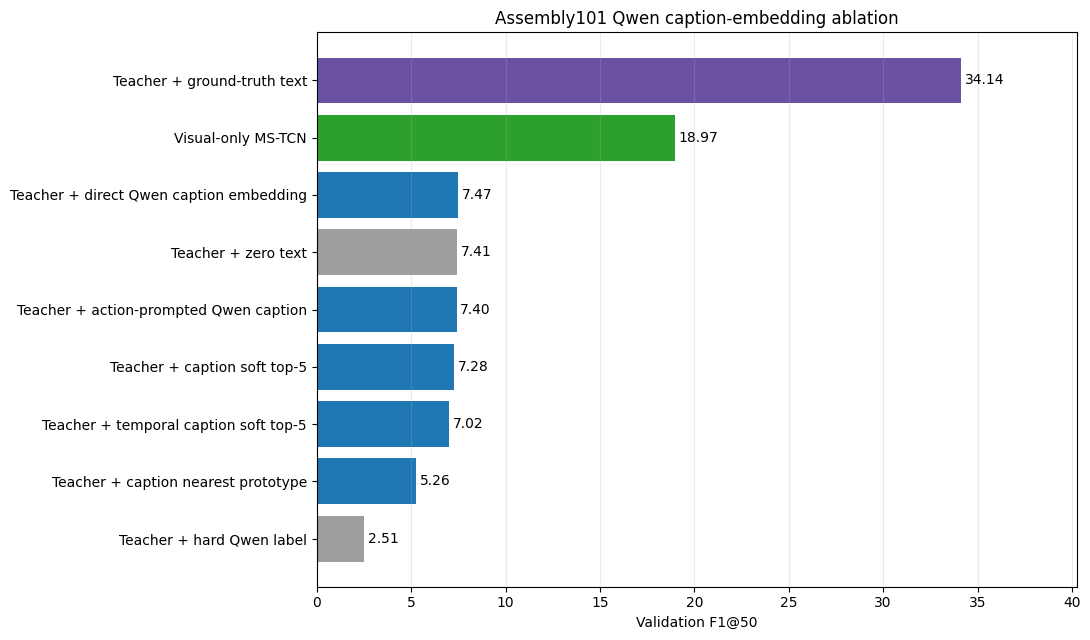

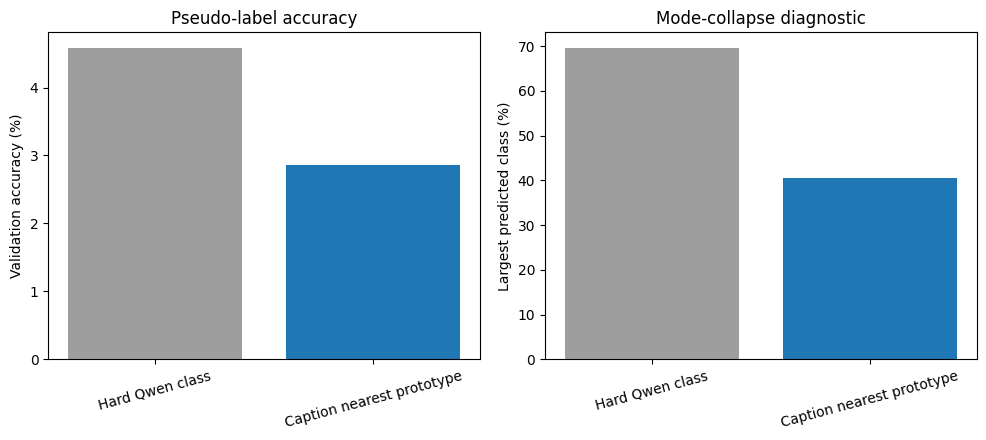

Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/26_qwen_caption_embedding_ablation/presentation_artifacts/caption_ablation_validation_f1_at_50.png
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/26_qwen_caption_embedding_ablation/presentation_artifacts/caption_retrieval_diagnostic.png


In [19]:
plot_df = final_metrics_df.sort_values("f1@50", ascending=True)
colors = [
    "#2CA02C" if key == "visual_only_mstcn"
    else "#6A51A3" if key == "oracle_gt_text"
    else "#1F77B4" if key in CAPTION_VARIANT_KEYS
    else "#9E9E9E"
    for key in plot_df["key"]
]

figure, axis = plt.subplots(figsize=(11, 6.5))
bars = axis.barh(plot_df["variant"], plot_df["f1@50"], color=colors)
axis.set_xlabel("Validation F1@50")
axis.set_title("Assembly101 Qwen caption-embedding ablation")
axis.grid(axis="x", alpha=0.25)
for bar, value in zip(bars, plot_df["f1@50"]):
    axis.text(
        bar.get_width() + 0.20,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
    )
axis.set_xlim(0, max(plot_df["f1@50"]) * 1.18)
figure.tight_layout()
f1_figure_path = ARTIFACT_ROOT / "caption_ablation_validation_f1_at_50.png"
figure.savefig(f1_figure_path, dpi=180, bbox_inches="tight")
plt.show()

collapse_df = pd.DataFrame(
    [
        {
            "method": "Hard Qwen class",
            "accuracy": retrieval_diagnostics["hard_qwen_accuracy_percent"],
            "largest_class_fraction": retrieval_diagnostics[
                "hard_qwen_largest_class_fraction_percent"
            ],
        },
        {
            "method": "Caption nearest prototype",
            "accuracy": retrieval_diagnostics["caption_top1_accuracy_percent"],
            "largest_class_fraction": retrieval_diagnostics[
                "caption_top1_largest_class_fraction_percent"
            ],
        },
    ]
)
figure, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar(collapse_df["method"], collapse_df["accuracy"], color=["#9E9E9E", "#1F77B4"])
axes[0].set_ylabel("Validation accuracy (%)")
axes[0].set_title("Pseudo-label accuracy")
axes[0].tick_params(axis="x", rotation=15)
axes[1].bar(
    collapse_df["method"],
    collapse_df["largest_class_fraction"],
    color=["#9E9E9E", "#1F77B4"],
)
axes[1].set_ylabel("Largest predicted class (%)")
axes[1].set_title("Mode-collapse diagnostic")
axes[1].tick_params(axis="x", rotation=15)
figure.tight_layout()
retrieval_figure_path = ARTIFACT_ROOT / "caption_retrieval_diagnostic.png"
figure.savefig(retrieval_figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", f1_figure_path)
print("Saved:", retrieval_figure_path)


## 20. Final summary


In [20]:
final_summary = {
    "status": "completed",
    "task": "Assembly101 Qwen caption-embedding validation ablation",
    "primary_metric": "F1@50",
    "data": {
        "split": "validation",
        "num_sequences": len(val_ids),
        "num_temporal_positions": len(captions_df),
        "test_accessed": False,
    },
    "source": {
        "qwen_model_id": QWEN_MODEL_ID,
        "qwen_prompt_sha256": PROMPT_HASH,
        "caption_corpus_sha256": CAPTION_CORPUS_SHA256,
        "caption_source": str(PARSED_PREDICTION_DIR),
        "qwen_rerun": False,
    },
    "clip": {
        "model": CLIP_MODEL_NAME,
        "prompt_template": ACTION_PROMPT_TEMPLATE,
        "prototype_reproduction": prototype_reproduction,
    },
    "retrieval": {
        "soft_top_k": SOFT_TOP_K,
        "softmax_temperature": SOFTMAX_TEMPERATURE,
        "temporal_kernel": TEMPORAL_KERNEL.astype(float).tolist(),
        "diagnostics": retrieval_diagnostics,
    },
    "teacher": {
        "checkpoint": str(TEACHER_CHECKPOINT),
        "checkpoint_epoch": int(teacher_checkpoint["epoch"]),
        "temporal_model": "mstcn",
        "video_representation": "clip_vitb16",
        "parameter_count": int(parameter_count),
        "notebook25_baselines_reproduced": True,
        "baseline_reproduction_tolerance": BASELINE_REPRO_TOLERANCE,
    },
    "validation_metrics": {
        row["key"]: {
            metric_name: float(row[metric_name])
            for metric_name in ["acc", "edit", "f1@10", "f1@25", "f1@50"]
        }
        for _, row in final_metrics_df.iterrows()
    },
    "decision": decision,
    "selection_policy": (
        "Promote only if the best fixed caption method beats hard Qwen "
        "and zero text and is not below visual-only validation F1@50."
    ),
    "next_step": (
        "Freeze the selected caption method and perform one test run."
        if decision["promote_to_test"]
        else "Do not access test; report the caption follow-up on validation."
    ),
    "artifacts": {
        "validation_metrics_csv": str(final_metrics_path),
        "validation_decision_json": str(decision_path),
        "source_captions_csv": str(captions_path),
        "retrieval_csv": str(retrieval_path),
        "retrieval_diagnostics_csv": str(diagnostics_path),
        "baseline_reproduction_csv": str(reproduction_path),
        "full_table_markdown": str(full_table_path),
        "deployable_table_markdown": str(deployable_table_path),
        "f1_at_50_figure": str(f1_figure_path),
        "retrieval_figure": str(retrieval_figure_path),
    },
    "created_utc": datetime.now(timezone.utc).isoformat(),
}

final_summary_path = OUT_ROOT / "final_summary.json"
final_summary_path.write_text(
    json.dumps(final_summary, indent=2),
    encoding="utf-8",
)

print(json.dumps(final_summary, indent=2))
print("Saved:", final_summary_path)

del teacher
gc.collect()
torch.cuda.empty_cache()


{
  "status": "completed",
  "task": "Assembly101 Qwen caption-embedding validation ablation",
  "primary_metric": "F1@50",
  "data": {
    "split": "validation",
    "num_sequences": 120,
    "num_temporal_positions": 1920,
    "test_accessed": false
  },
  "source": {
    "qwen_model_id": "Qwen/Qwen3.5-2B",
    "qwen_prompt_sha256": "08047fb92444d9b043a3894ab2c9f91e516a9e466d02e52f67446ed9551701b6",
    "caption_corpus_sha256": "8d8cce5e96853681529a874bf3953e7e1ca8e31f3a2efa1fc31887ebef7d328b",
    "caption_source": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/24_qwen35_pseudotext/qwen35_2b_closedset_temporal_v1/parsed_predictions",
    "qwen_rerun": false
  },
  "clip": {
    "model": "ViT-B/16",
    "prompt_template": "a video of a person performing the action: {}",
    "prototype_reproduction": {
      "minimum_cosine": 0.9999998807907104,
      "mean_cosine": 1.0,
      "maximum_absolute_difference": 

## Interpretation rules

- A successful notebook execution does not imply that captions help.
  Use `decision.promote_to_test`, not completion status.
- `caption_direct` tests the stored caption as written, while
  `caption_prompted` adds the same action prefix used for teacher text.
- `caption_top1` tests whether caption semantics can recover a valid
  Assembly101 action without trusting Qwen's hard class ID.
- Soft top-5 variants test whether uncertainty and temporal consistency
  reduce the damage from incorrect hard pseudo-labels.
- Validation labels are used only for diagnostics and evaluation, after
  every caption-derived text input has already been constructed.
- If no caption method beats zero text, the correct conclusion is a
  negative follow-up. Do not tune the prompt or retrieval on test data.
